# SPX Options Greeks, ES Delta Hedging, and Scenario Analysis

## Project Objective

This project builds a market risk framework for SPX index options using the Black-Scholes model.

The goal is not to build a production-level pricing engine. The goal is to show how option prices and Greeks change across market inputs, and how Delta exposure can be hedged with ES futures while residual option risks remain.

## Workflow

1. Pull recent SPX market data.
2. Estimate 1-year historical volatility from daily SPX returns.
3. Build Black-Scholes pricing functions for European calls and puts.
4. Calculate Delta, Gamma, Vega, Theta, and Rho.
5. Analyze Greeks across strikes, maturities, and volatility assumptions.
6. Apply the Greeks framework to a real SPX call option chain.
7. Select a near-ATM SPX call and calculate portfolio Delta exposure.
8. Hedge the Delta exposure with ES futures.
9. Measure residual Greeks after the Delta hedge.
10. Run scenario analysis under SPX index shocks and volatility shocks.

## Key Risk Concepts

- Delta measures first-order directional exposure to SPX moves.
- Gamma measures how quickly Delta changes when SPX moves.
- Vega measures sensitivity to volatility shocks.
- Theta measures daily time decay.
- Rho measures interest-rate sensitivity.
- Delta-neutral does not mean risk-free because Gamma, Vega, Theta, and Rho exposures remain.

## Data and Assumptions

- Underlying index: SPX
- Market data source: Yahoo Finance via `yfinance`
- Historical volatility: estimated from 1-year SPX daily returns
- Option type: European-style SPX index option
- Dividend yield: set to `q = 0` as a simplification
- Risk-free rate: fixed at 4% in the model examples
- ES futures multiplier: 50 dollars per SPX index point
- SPX option multiplier: 100 dollars per SPX index point

## Main Takeaway

The project shows the full risk workflow: identify option exposures, calculate Greeks, hedge first-order Delta risk, measure residual Greeks, and stress test the hedged position under index and volatility shocks.

In [35]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Market data
import yfinance as yf

# Display settings
pd.set_option("display.precision", 6)
pd.set_option("display.max_columns", None)


## SPX Market Data and Volatility Input

- Pull 1 year of SPX historical market data.
- Use the latest SPX close as the current underlying index level.
- Calculate daily simple returns from SPX close prices.
- Estimate annualized historical volatility from daily returns.

Formula:

Simple return:

$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

Annualized historical volatility:

$$
\sigma_{annual} = \sigma_{daily} \times \sqrt{252}
$$

where 252 is the approximate number of trading days in one year.

Risk takeaway:

- SPX level is the underlying price input for option pricing.
- Historical volatility is used as a baseline volatility assumption.
- This is realized volatility, not implied volatility.
- In real option markets, implied volatility and volatility surface would be more important.

In [36]:
# Pull recent SPX market data

spx = yf.Ticker("^SPX")

spx_hist = spx.history(period="1y")
spx_price = spx_hist["Close"].iloc[-1]

# Estimate annualized historical volatility from daily returns
spx_returns = spx_hist["Close"].pct_change().dropna()
hist_vol = spx_returns.std() * np.sqrt(252)

print(f"Latest SPX Price: {spx_price:.2f}")
print(f"Estimated 1Y Historical Volatility: {hist_vol:.2%}")

Latest SPX Price: 7501.24
Estimated 1Y Historical Volatility: 12.10%


In [37]:
expirations = spx.options
expirations[:5]

('2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20')

## Black-Scholes Pricing Functions

- Define pricing functions for European call and put options.
- Use the same market inputs for both calls and puts:
  - current index level
  - strike price
  - risk-free rate
  - volatility
  - time to maturity
  - dividend yield (set dividend yield `q = 0` as a simplification in this project)
- Return intrinsic value if the option is already at maturity.

Model inputs:

$$
S = \text{current underlying index level}
$$

$$
K = \text{strike price}
$$

$$
r = \text{risk-free rate}
$$

$$
\sigma = \text{volatility}
$$

$$
T = \text{time to maturity}
$$

$$
q = \text{dividend yield}
$$

Black-Scholes variables:

$$
d_1 = \frac{\ln(S/K) + (r - q + 0.5\sigma^2)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

Interpretation:

- `d1` is closely related to option sensitivity and Delta.
- `d2` is more closely related to the risk-neutral probability of exercise.
- Both variables convert moneyness, volatility, time, rates, and dividend yield into the Black-Scholes pricing framework.

European call price:

$$
C = S e^{-qT}N(d_1) - K e^{-rT}N(d_2)
$$

European put price:

$$
P = K e^{-rT}N(-d_2) - S e^{-qT}N(-d_1)
$$

At maturity:

$$
Call = \max(S-K, 0)
$$

$$
Put = \max(K-S, 0)
$$

Key point:

- This cell builds the pricing foundation for the later Greeks calculation.
- Price comes first; Greeks measure how that price changes when market inputs change.

In [38]:
# Black-Scholes pricing functions for European call and put options

def black_scholes_call(S, K, r, sigma, T, q=0.0):
    if S <= 0 or K <= 0:
        raise ValueError("Underlying index level and strike must be positive")
    if sigma <= 0:
        raise ValueError("Volatility must be positive")
    if T <= 0:
        return max(S - K, 0.0)

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price


def black_scholes_put(S, K, r, sigma, T, q=0.0):
    if S <= 0 or K <= 0:
        raise ValueError("Underlying index level and strike must be positive")
    if sigma <= 0:
        raise ValueError("Volatility must be positive")
    if T <= 0:
        return max(K - S, 0.0)

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    return put_price

## Black-Scholes Greeks

- Calculate option Greeks for European call and put options.
- Use the same Black-Scholes inputs and `d1 / d2` structure from the pricing function. Set dividend yield `q = 0` as a simplification in this project.
- Convert option pricing into risk sensitivity analysis.
- Calculate Delta, Gamma, Vega, Theta, and Rho.
- Add a wrapper function to convert days to maturity into years.

Inputs:

$$
S = \text{current SPX index level}
$$

$$
K = \text{strike price}
$$

$$
r = \text{risk-free rate}
$$

$$
\sigma = \text{annualized volatility}
$$

$$
T = \text{time to maturity in years}
$$

$$
q = \text{dividend yield}
$$

Core variables:

$$
d_1 = \frac{\ln(S/K) + (r - q + 0.5\sigma^2)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

Greeks:

Delta measures first-order directional exposure.

$$
\Delta_{call} = e^{-qT}N(d_1)
$$

$$
\Delta_{put} = e^{-qT}(N(d_1)-1)
$$

Gamma measures how Delta changes when SPX moves.

$$
\Gamma = \frac{e^{-qT}\phi(d_1)}{S\sigma\sqrt{T}}
$$

Vega measures sensitivity to a 1% change in volatility.

$$
Vega = \frac{S e^{-qT}\phi(d_1)\sqrt{T}}{100}
$$

Theta measures daily time decay.

$$
Theta = \frac{\text{annual theta}}{365}
$$

Rho measures sensitivity to a 1% change in interest rates.

$$
Rho_{call} = \frac{KTe^{-rT}N(d_2)}{100}
$$

$$
Rho_{put} = \frac{-KTe^{-rT}N(-d_2)}{100}
$$

Risk interpretation:

- Delta shows the first-order exposure to SPX movement.
- Gamma shows how stable or unstable the Delta hedge is.
- Vega shows exposure to volatility shocks.
- Theta shows daily time decay.
- Rho shows interest-rate sensitivity.
- Delta-neutral does not mean risk-free because Gamma, Vega, Theta, and Rho exposures can remain.

In [39]:
# Black-Scholes Greeks for European options

def black_scholes_greeks(S, K, r, sigma, T, q=0.0) -> dict:
    """
    Calculate Delta, Gamma, Vega, Theta, and Rho for European call and put options.

    S: underlying index level
    K: strike price
    r: risk-free rate
    sigma: annualized volatility
    T: time to maturity in years
    q: dividend yield
    """

    if S <= 0 or K <= 0:
        raise ValueError("Underlying index level and strike must be positive")
    if sigma <= 0:
        raise ValueError("Volatility must be positive")

    if T <= 0:
        if S > K:
            delta_call, delta_put = 1.0, 0.0
        elif S < K:
            delta_call, delta_put = 0.0, -1.0
        else:
            delta_call, delta_put = 0.5, -0.5

        return {
            "Delta (Call)": delta_call,
            "Delta (Put)": delta_put,
            "Gamma": 0.0,
            "Vega": 0.0,
            "Theta (Call)": 0.0,
            "Theta (Put)": 0.0,
            "Rho (Call)": 0.0,
            "Rho (Put)": 0.0
        }

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    exp_qt = np.exp(-q * T)
    exp_rt = np.exp(-r * T)
    pdf_d1 = norm.pdf(d1)

    # Delta
    delta_call = exp_qt * norm.cdf(d1)
    delta_put = exp_qt * (norm.cdf(d1) - 1)

    # Gamma: same for call and put
    gamma = exp_qt * pdf_d1 / (S * sigma * np.sqrt(T))

    # Vega: per 1% change in volatility
    vega = S * exp_qt * pdf_d1 * np.sqrt(T) / 100

    # Theta: per day
    theta_call = (
        -(S * exp_qt * pdf_d1 * sigma) / (2 * np.sqrt(T))
        - r * K * exp_rt * norm.cdf(d2)
        + q * S * exp_qt * norm.cdf(d1)
    ) / 365

    theta_put = (
        -(S * exp_qt * pdf_d1 * sigma) / (2 * np.sqrt(T))
        + r * K * exp_rt * norm.cdf(-d2)
        - q * S * exp_qt * norm.cdf(-d1)
    ) / 365

    # Rho: per 1% change in interest rate
    rho_call = K * T * exp_rt * norm.cdf(d2) / 100
    rho_put = -K * T * exp_rt * norm.cdf(-d2) / 100

    return {
        "Delta (Call)": delta_call,
        "Delta (Put)": delta_put,
        "Gamma": gamma,
        "Vega": vega,
        "Theta (Call)": theta_call,
        "Theta (Put)": theta_put,
        "Rho (Call)": rho_call,
        "Rho (Put)": rho_put
    }


def bsm_greeks(S, X, sigma, r, q, t) -> dict:
    """
    Wrapper using days to maturity.
    X: strike price
    t: time to maturity in days
    """
    T = t / 365
    return black_scholes_greeks(S, X, r, sigma, T, q=q)

## SPX Greeks Across Strikes

Fix one set of baseline assumptions: current SPX level, historical volatility, 4% risk-free rate, 0% dividend yield, and 30 days to maturity.

Calculate Black-Scholes call / put prices and Greeks across different strike prices around the current SPX level.

Moneyness formula:

$$
Moneyness = \frac{S}{K}
$$

Call and put status are shown separately because call and put payoffs move in opposite directions.

Call moneyness group:

- ITM if `S / K > 1.02`
- ATM / near-ATM if `0.98 <= S / K <= 1.02`
- OTM if `S / K < 0.98`

Put moneyness group:

- OTM if `S / K > 1.02`
- ATM / near-ATM if `0.98 <= S / K <= 1.02`
- ITM if `S / K < 0.98`

The ±2% band groups strikes close to the current SPX level as near-ATM, making the comparison of prices and Greeks across strikes easier to read.

Key point:

- As strike changes, moneyness changes.
- Call and put ITM / OTM status move in opposite directions.
- Delta, Gamma, Vega, Theta, and Rho change across ITM, near-ATM, and OTM strikes.

In [40]:
# Baseline assumptions for SPX option analysis
S_test = spx_price
X_test = round(spx_price / 5) * 5
sigma_test = hist_vol
r_test = 0.04
q_test = 0.00
t_test = 30

# SPX Greeks across strikes
def create_greeks_across_strikes(S, K_range, sigma, r, q, t):
    """
    Calculate Black-Scholes option prices and Greeks across different strike prices.
    """

    results = []

    for K in K_range:
        call_price = black_scholes_call(S, K, r, sigma, t / 365, q=q)
        put_price = black_scholes_put(S, K, r, sigma, t / 365, q=q)
        greeks = bsm_greeks(S, K, sigma, r, q, t)

        moneyness = S / K

        if moneyness > 1.02:
          call_status = "ITM"
          put_status = "OTM"
        elif moneyness < 0.98:
          call_status = "OTM"
          put_status = "ITM"
        else:
          call_status = "ATM"
          put_status = "ATM"

        results.append({
            "Strike": K,
            "Moneyness": moneyness,
            "Call Status": call_status,
            "Put Status": put_status,
            "Call Price": call_price,
            "Put Price": put_price,
            "Delta (Call)": greeks["Delta (Call)"],
            "Delta (Put)": greeks["Delta (Put)"],
            "Gamma": greeks["Gamma"],
            "Vega": greeks["Vega"],
            "Theta (Call)": greeks["Theta (Call)"],
            "Theta (Put)": greeks["Theta (Put)"],
            "Rho (Call)": greeks["Rho (Call)"],
            "Rho (Put)": greeks["Rho (Put)"]
        })

    return pd.DataFrame(results)


# Create strike range around current SPX index level
K_range_dashboard = [
    round((S_test * 0.90) / 5) * 5,
    round((S_test * 0.95) / 5) * 5,
    round((S_test * 0.98) / 5) * 5,
    round(S_test / 5) * 5,
    round((S_test * 1.02) / 5) * 5,
    round((S_test * 1.05) / 5) * 5,
    round((S_test * 1.10) / 5) * 5
]

dashboard = create_greeks_across_strikes(
    S=S_test,
    K_range=K_range_dashboard,
    sigma=sigma_test,
    r=r_test,
    q=q_test,
    t=t_test
)

print("=" * 100)
print("SPX GREEKS ACROSS STRIKES")
print("=" * 100)
print(f"Index Level:       {S_test:.2f}")
print(f"Volatility:        {sigma_test * 100:.1f}%")
print(f"Risk-Free Rate:    {r_test * 100:.1f}%")
print(f"Time to Maturity:  {t_test} days")
print("=" * 100)

display(dashboard.round(6))

SPX GREEKS ACROSS STRIKES
Index Level:       7501.24
Volatility:        12.1%
Risk-Free Rate:    4.0%
Time to Maturity:  30 days


,Strike,Moneyness,Call Status,Put Status,Call Price,Put Price,Delta (Call),Delta (Put),Gamma,Vega,Theta (Call),Theta (Put),Rho (Call),Rho (Put)
0,6750,1.111295,ITM,OTM,773.453347,0.057772,0.999193,-0.000807,0.000011,0.059450,-0.748620,-0.011322,5.524713,-0.005022
1,7125,1.052806,ITM,OTM,405.826583,6.200156,0.944662,-0.055338,0.000429,2.403900,-1.216986,-0.438727,5.490666,-0.346276
2,7350,1.020577,ITM,OTM,213.260416,37.895477,0.757761,-0.242239,0.001200,6.719287,-1.954916,-1.152080,4.496618,-1.524649
3,7500,1.000165,ATM,ATM,117.091891,91.234611,0.546517,-0.453483,0.001522,8.521020,-2.155234,-1.336014,3.273258,-2.870892
4,7650,0.980554,ATM,ATM,54.269925,177.920304,0.324967,-0.675033,0.001383,7.739778,-1.822406,-0.986801,1.958946,-4.308087
5,7875,0.952538,OTM,ITM,11.950162,359.862029,0.098649,-0.901351,0.000668,3.736810,-0.833548,0.026633,0.598388,-5.852970
6,8250,0.909241,OTM,ITM,0.342697,722.023712,0.004269,-0.995731,0.000048,0.270055,-0.057945,0.843197,0.026039,-6.732527


## Plot Selected Greeks Across Strikes

Plot selected Greeks across strike prices using the same baseline SPX assumptions.

Strike prices are model-generated around the current SPX level, from 90% to 110% of spot, rounded to the nearest 5. This section is used to show how Greeks change across moneyness, not to analyze a real option chain.

- Call Delta ranges from `0` to `1`.
- Put Delta ranges from `-1` to `0`.
- Call Delta and Put Delta move in opposite directions across strikes.
- Gamma and Vega are the same for European calls and puts under Black-Scholes, so each is plotted once.
- Gamma and Vega are plotted separately because they have different units and scales.

Key point:

- Delta shows directional exposure.
- Gamma is highest around ATM, where Delta changes fastest.
- Vega is highest around ATM, where option value is most sensitive to volatility changes.

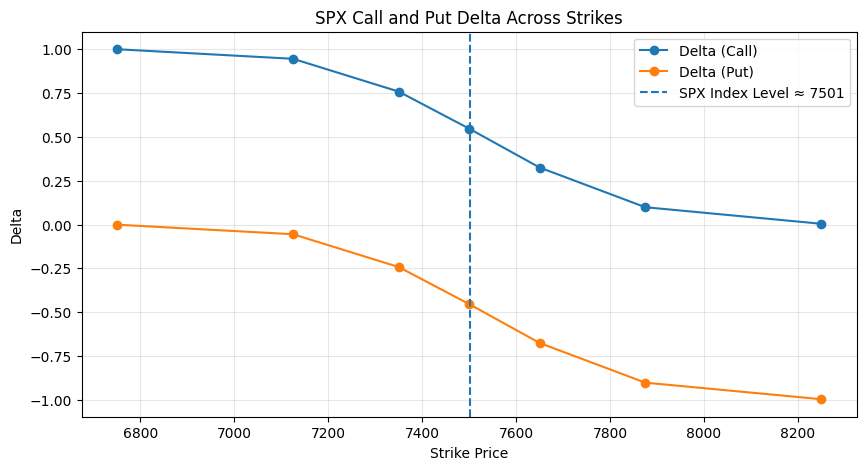

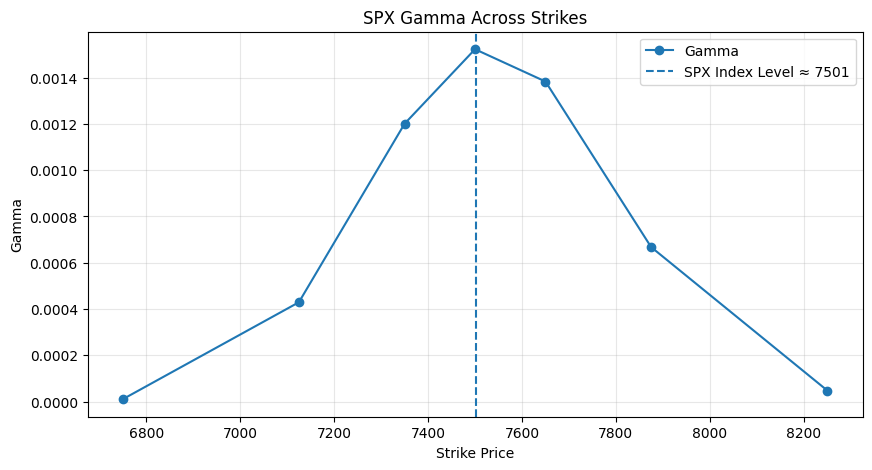

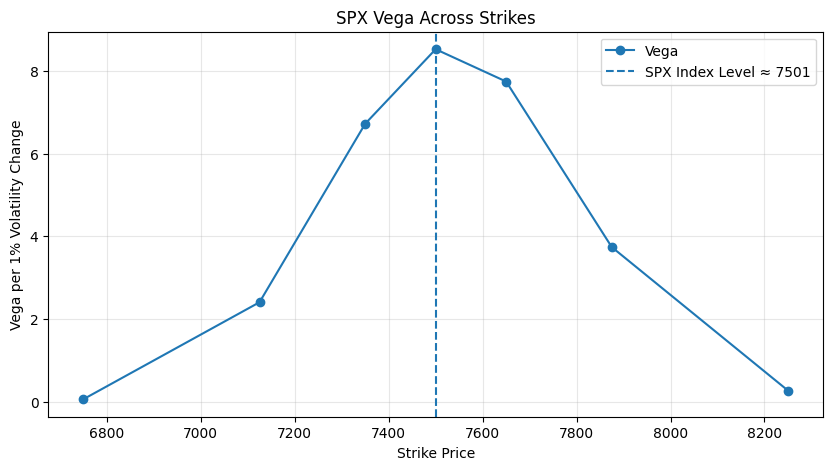

In [41]:
# Plot selected Greeks across strikes

# Delta across strikes: call and put
plt.figure(figsize=(10, 5))
plt.plot(dashboard["Strike"], dashboard["Delta (Call)"], marker="o", label="Delta (Call)")
plt.plot(dashboard["Strike"], dashboard["Delta (Put)"], marker="o", label="Delta (Put)")
plt.axvline(x=S_test, linestyle="--", label=f"SPX Index Level ≈ {S_test:.0f}")

plt.title("SPX Call and Put Delta Across Strikes")
plt.xlabel("Strike Price")
plt.ylabel("Delta")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Gamma across strikes
plt.figure(figsize=(10, 5))
plt.plot(dashboard["Strike"], dashboard["Gamma"], marker="o", label="Gamma")
plt.axvline(x=S_test, linestyle="--", label=f"SPX Index Level ≈ {S_test:.0f}")

plt.title("SPX Gamma Across Strikes")
plt.xlabel("Strike Price")
plt.ylabel("Gamma")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Vega across strikes
plt.figure(figsize=(10, 5))
plt.plot(dashboard["Strike"], dashboard["Vega"], marker="o", label="Vega")
plt.axvline(x=S_test, linestyle="--", label=f"SPX Index Level ≈ {S_test:.0f}")

plt.title("SPX Vega Across Strikes")
plt.xlabel("Strike Price")
plt.ylabel("Vega per 1% Volatility Change")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## SPX Call Greeks Across Maturities and Volatility Levels

Fix one near-ATM SPX call option and vary two assumptions:

- maturity: 30, 60, 90, and 180 days
- volatility: 10%, 20%, 30%, and 40%

Calculate Black-Scholes call price and model-implied Greeks under each scenario.

Formula:

$$
T = \frac{\text{days to maturity}}{365}
$$

Key point:

- This section shows how call price and Greeks change when maturity and volatility assumptions change.
- Call price increases when maturity is longer or volatility is higher.
- Vega increases with longer maturity, showing that longer-dated options are more sensitive to volatility shocks.
- Gamma is higher for shorter-dated near-ATM options, showing that Delta can change faster.
- Theta is usually negative for long calls, showing daily time decay as the option loses time value.

In [42]:
# SPX call Greeks across maturities and volatility levels

maturities = [30, 60, 90, 180]
vol_levels = [0.10, 0.20, 0.30, 0.40]

sensitivity_data = []

for t in maturities:
    for sigma in vol_levels:
        greeks = bsm_greeks(S_test, X_test, sigma, r_test, q_test, t)
        call_price = black_scholes_call(S_test, X_test, r_test, sigma, t / 365, q=q_test)

        sensitivity_data.append({
            "Maturity (Days)": t,
            "Volatility (%)": sigma * 100,
            "Call Price": call_price,
            "Delta": greeks["Delta (Call)"],
            "Gamma": greeks["Gamma"],
            "Vega": greeks["Vega"],
            "Theta": greeks["Theta (Call)"],
            "Rho": greeks["Rho (Call)"]
        })

sensitivity_df = pd.DataFrame(sensitivity_data)

print("=" * 100)
print("SPX GREEKS ACROSS MATURITIES AND VOLATILITY LEVELS")
print("=" * 100)
print(f"Index Level:  {S_test:.2f}")
print(f"Strike Price: {X_test:.2f}")
print("=" * 100)

display(sensitivity_df.round(6))

SPX GREEKS ACROSS MATURITIES AND VOLATILITY LEVELS
Index Level:  7501.24
Strike Price: 7500.00


,Maturity (Days),Volatility (%),Call Price,Delta,Gamma,Vega,Theta,Rho
0,30,10.0,99.192331,0.553607,0.001838,8.501837,-1.861197,3.331679
1,30,20.0,184.507996,0.535416,0.000924,8.545579,-3.268447,3.149404
2,30,30.0,269.994965,0.533135,0.000616,8.549800,-4.683577,3.065076
3,30,40.0,355.480909,0.534843,0.000462,8.546666,-6.098490,3.005345
4,60,10.0,147.779107,0.573984,0.001289,11.923870,-1.449307,6.834766
5,60,20.0,267.812160,0.549212,0.000651,12.040683,-2.428913,6.331993
6,60,30.0,388.299965,0.546267,0.000434,12.051429,-3.419365,6.097608
7,60,40.0,508.777989,0.548809,0.000325,12.042195,-4.409459,5.930907
8,90,10.0,188.271864,0.589704,0.001044,14.482713,-1.268731,10.443055
9,90,20.0,334.524276,0.559868,0.000529,14.692333,-2.056063,9.530577


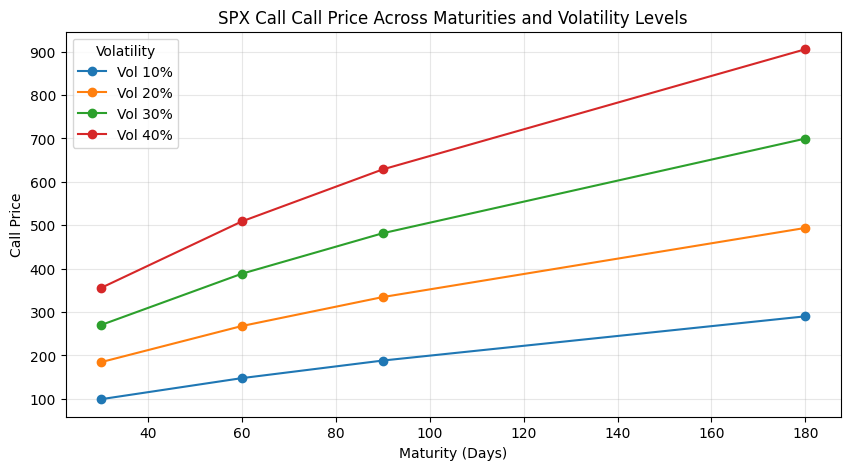

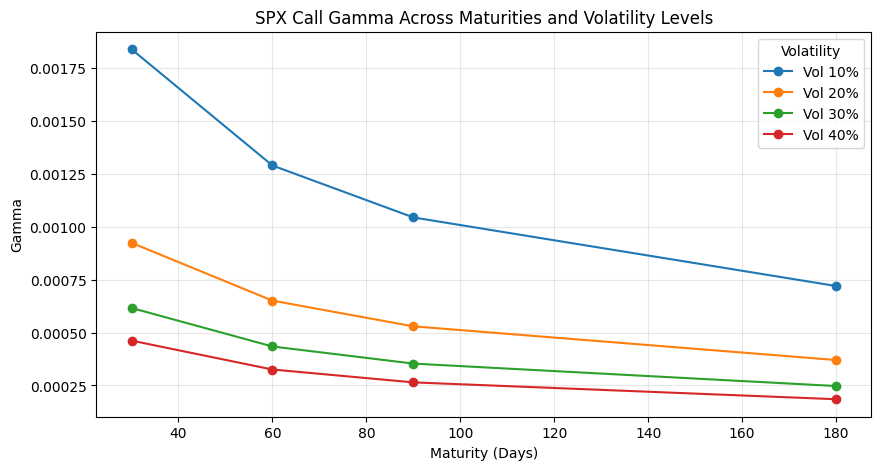

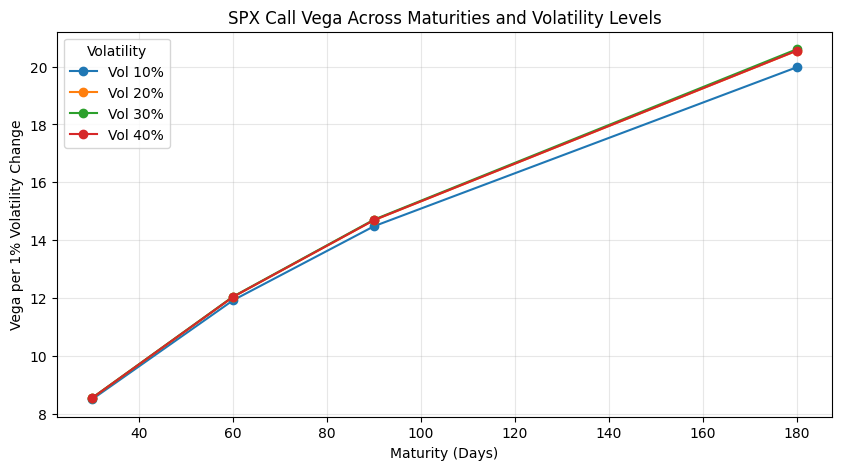

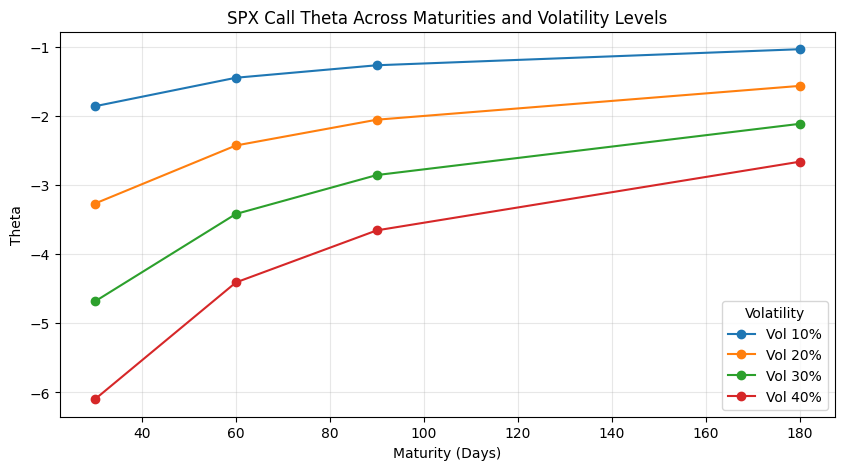

In [43]:
# Plot Call Price, Gamma, Vega, and Theta across maturities and volatility levels

metrics_to_plot = ["Call Price", "Gamma", "Vega", "Theta"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 5))

    for vol in sorted(sensitivity_df["Volatility (%)"].unique()):
        subset = sensitivity_df[sensitivity_df["Volatility (%)"] == vol]

        plt.plot(
            subset["Maturity (Days)"],
            subset[metric],
            marker="o",
            label=f"Vol {vol:.0f}%"
        )

    plt.title(f"SPX Call {metric} Across Maturities and Volatility Levels")
    plt.xlabel("Maturity (Days)")

    if metric == "Vega":
        plt.ylabel("Vega per 1% Volatility Change")
    else:
        plt.ylabel(metric)

    plt.legend(title="Volatility")
    plt.grid(True, alpha=0.3)
    plt.show()

## Real SPX Call Option Chain Greeks

Pull the recent SPX call option chain and select near-ATM calls with 20–60 days to maturity.

Use real market inputs from the option chain:

- SPX index level
- expiration date
- strike price
- implied volatility

Calculate model-implied Greeks for each near-ATM call using the Black-Scholes framework:

- Delta
- Gamma
- Vega
- Theta
- Rho

This section connects the model to real option-chain inputs. The selected near-ATM call Delta is then used in the ES futures Delta hedge calculation.


In [49]:
# Apply Greeks framework to recent SPX call option chain

print("=" * 100)
print("REAL SPX CALL OPTION CHAIN GREEKS")
print("=" * 100)

# Get available SPX option expirations
expirations = spx.options

# Choose an expiration around 20-60 days
today = pd.Timestamp.today().normalize()
valid_expirations = []

for exp in expirations:
    days = (pd.Timestamp(exp) - today).days
    if 20 <= days <= 60:
        valid_expirations.append((exp, days))

if len(valid_expirations) == 0:
    raise ValueError("No SPX expiration found between 20 and 60 days.")

exp_date, days_to_maturity = valid_expirations[0]

# Pull SPX call option chain
chain = spx.option_chain(exp_date)
calls = chain.calls.copy()

# Focus on near-ATM calls
calls["Distance to Index"] = abs(calls["strike"] - spx_price)
calls_near_atm = calls.sort_values("Distance to Index").head(10).copy()

# Calculate model-implied Greeks using real option-chain strikes and maturity
market_greeks_data = []

r_chain = 0.04
q_chain = 0.00

for _, row in calls_near_atm.iterrows():
    K = row["strike"]
    implied_vol = row["impliedVolatility"]

    # Fix bad / unrealistic Yahoo implied volatility values
    if pd.notna(implied_vol) and 0.05 <= implied_vol <= 1.00:
        sigma_used = implied_vol
        vol_source = "Option Chain IV"
    else:
        sigma_used = hist_vol
        vol_source = "Hist Vol Fallback"

    greeks = bsm_greeks(
        S=spx_price,
        X=K,
        sigma=sigma_used,
        r=r_chain,
        q=q_chain,
        t=days_to_maturity
    )

    market_greeks_data.append({
        "Strike": K,
        "Distance to Index": abs(K - spx_price),
        "Moneyness": spx_price / K,
        "Raw Implied Vol (%)": implied_vol * 100 if pd.notna(implied_vol) else np.nan,
        "Vol Used (%)": sigma_used * 100,
        "Vol Source": vol_source,
        "Delta": greeks["Delta (Call)"],
        "Gamma": greeks["Gamma"],
        "Vega": greeks["Vega"],
        "Theta": greeks["Theta (Call)"],
        "Rho": greeks["Rho (Call)"]
    })

market_greeks_df = pd.DataFrame(market_greeks_data)

print(f"SPX Index Level:   {spx_price:.2f}")
print(f"Expiration Date:   {exp_date}")
print(f"Days to Maturity:  {days_to_maturity}")
print("=" * 100)

display(market_greeks_df.round(6))

REAL SPX CALL OPTION CHAIN GREEKS
SPX Index Level:   7501.24
Expiration Date:   2026-06-04
Days to Maturity:  20


,Strike,Distance to Index,Moneyness,Raw Implied Vol (%),Vol Used (%),Vol Source,Delta,Gamma,Vega,Theta,Rho
0,7500.0,1.240234,1.000165,0.001000,12.102772,Hist Vol Fallback,0.538782,0.001868,6.971931,-2.542121,2.163142
1,7525.0,23.759766,0.996843,0.391621,12.102772,Hist Vol Fallback,0.491983,0.001877,7.003643,-2.514622,1.977675
2,7475.0,26.240234,1.003510,0.001000,12.102772,Hist Vol Fallback,0.585203,0.001834,6.844683,-2.540274,2.346414
3,7460.0,41.240234,1.005528,0.001000,12.102772,Hist Vol Fallback,0.612609,0.001802,6.724104,-2.525355,2.454237
4,7550.0,48.759766,0.993542,0.391621,12.102772,Hist Vol Fallback,0.445448,0.001860,6.939464,-2.458200,1.792656
5,7450.0,51.240234,1.006878,0.001000,12.102772,Hist Vol Fallback,0.630611,0.001776,6.626193,-2.509861,2.524892
6,7440.0,61.240234,1.008231,0.001000,12.102772,Hist Vol Fallback,0.648355,0.001746,6.514928,-2.490095,2.594387
7,7430.0,71.240234,1.009588,0.001000,12.102772,Hist Vol Fallback,0.665805,0.001713,6.390974,-2.466228,2.662575
8,7575.0,73.759766,0.990263,0.782242,12.102772,Hist Vol Fallback,0.399803,0.001818,6.782940,-2.374443,1.610666
9,7425.0,76.240234,1.010268,0.001000,12.102772,Hist Vol Fallback,0.674409,0.001695,6.324468,-2.452817,2.696135


## Delta Hedge with ES Futures

Select the near-ATM SPX call from the real SPX option chain.  

Use the selected call’s model-implied Delta to calculate the option position’s Delta exposure and hedge it with ES futures.

Inputs:

- Call Delta: model-implied Delta from the selected near-ATM SPX call
- Number of SPX option contracts: 10
- SPX option multiplier: 100 dollars per SPX index point
- ES futures multiplier: 50 dollars per SPX index point

Total Delta exposure:

$$
\text{Total Delta Exposure}
=
\Delta_{\text{call}}
\times
\text{Contracts}
\times
100
$$

ES hedge ratio:

$$
\text{ES Hedge Contracts}
=
-\frac{\text{Total Delta Exposure}}{50}
$$

Net Delta exposure after hedge:

$$
\text{Net Delta Exposure}
=
\text{Option Delta Exposure}
+
\text{ES Hedge Contribution}
$$

Key point:

- A long SPX call has positive Delta exposure.
- Short ES futures offset that first-order SPX directional exposure.
- The hedge is calculated in dollar-per-index-point exposure, not total notional value.
- Delta-neutral does not mean risk-free; Gamma, Vega, Theta, and Rho exposures remain.
- The ES hedge ratio is theoretical and would be rounded or implemented using ES / MES contracts in practice.

In [50]:
# Simple delta hedge example using a near-ATM SPX call option

# Select the near-ATM call from real SPX option chain
market_greeks_df["Distance to Index"] = abs(market_greeks_df["Strike"] - spx_price)
selected_option = market_greeks_df.sort_values("Distance to Index").iloc[0]

selected_strike = selected_option["Strike"]
selected_delta = selected_option["Delta"]
selected_gamma = selected_option["Gamma"]
selected_vega = selected_option["Vega"]
selected_theta = selected_option["Theta"]
selected_rho = selected_option["Rho"]

contracts = 10
option_multiplier = 100   # SPX option multiplier: $100 per index point
es_multiplier = 50        # ES futures multiplier: $50 per index point

# Delta exposure of the SPX option position
total_delta_exposure = selected_delta * contracts * option_multiplier

# Hedge with ES futures
hedge_es_contracts = -total_delta_exposure / es_multiplier

print("=" * 100)
print("SIMPLE DELTA HEDGE EXAMPLE - SPX OPTIONS WITH ES FUTURES")
print("=" * 100)
print(f"Selected SPX Call Strike:          {selected_strike:.2f}")
print(f"SPX Index Level:                   {spx_price:.2f}")
print(f"Call Delta:                        {selected_delta:.4f}")
print(f"Number of SPX Option Contracts:    {contracts}")
print(f"SPX Option Multiplier:             {option_multiplier}")
print(f"Total Delta Exposure:              {total_delta_exposure:.2f} dollars per SPX index point")
print(f"ES Futures Multiplier:             {es_multiplier}")
print(f"Required ES Futures Hedge:         {hedge_es_contracts:.2f} ES contracts")
print("=" * 100)

if hedge_es_contracts < 0:
    print(f"To make the position approximately delta-neutral, short {abs(hedge_es_contracts):.2f} ES futures contracts.")
else:
    print(f"To make the position approximately delta-neutral, buy {hedge_es_contracts:.2f} ES futures contracts.")

print("Note: The hedge is shown as a theoretical hedge ratio. In practice, the futures position would be rounded or implemented using ES/MES contracts.")

SIMPLE DELTA HEDGE EXAMPLE - SPX OPTIONS WITH ES FUTURES
Selected SPX Call Strike:          7500.00
SPX Index Level:                   7501.24
Call Delta:                        0.5388
Number of SPX Option Contracts:    10
SPX Option Multiplier:             100
Total Delta Exposure:              538.78 dollars per SPX index point
ES Futures Multiplier:             50
Required ES Futures Hedge:         -10.78 ES contracts
To make the position approximately delta-neutral, short 10.78 ES futures contracts.
Note: The hedge is shown as a theoretical hedge ratio. In practice, the futures position would be rounded or implemented using ES/MES contracts.


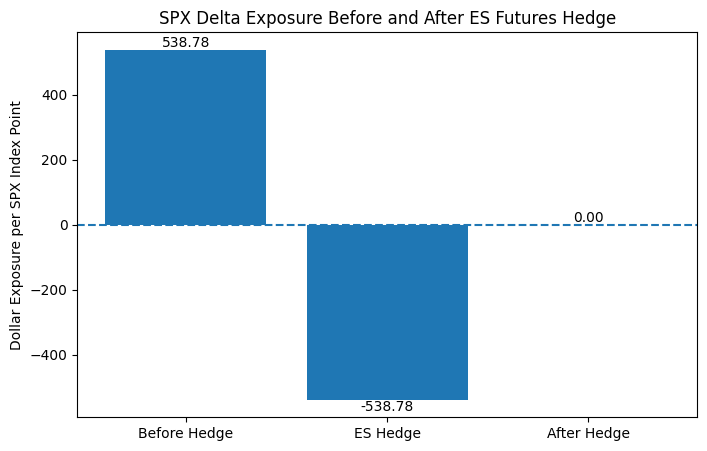

In [51]:
# Plot delta exposure before and after ES futures hedge

before_hedge = total_delta_exposure
hedge_contribution = hedge_es_contracts * es_multiplier
after_hedge = before_hedge + hedge_contribution  # should be close to 0

plt.figure(figsize=(8, 5))

plt.bar(
    ["Before Hedge", "ES Hedge", "After Hedge"],
    [before_hedge, hedge_contribution, after_hedge]
)

plt.axhline(y=0, linestyle="--")
plt.title("SPX Delta Exposure Before and After ES Futures Hedge")
plt.ylabel("Dollar Exposure per SPX Index Point")

for i, v in enumerate([before_hedge, hedge_contribution, after_hedge]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom" if v >= 0 else "top")

plt.show()

## Residual Greeks After ES Delta Hedge

Calculate the remaining portfolio Greeks after the ES futures Delta hedge.

The ES futures hedge offsets the option position’s Delta exposure, but it does not remove the option’s nonlinear and non-directional risks.

Portfolio-level Greeks:

$$
\text{Portfolio Greek}
=
\text{Selected Option Greek}
\times
\text{Contracts}
\times
100
$$

Residual Delta after hedge:

$$
\text{Residual Delta}
=
\text{Option Delta Exposure}
+
\text{ES Hedge Contribution}
$$

Key point:

- ES futures reduce the first-order SPX directional exposure.
- Gamma remains, so Delta can change again when SPX moves.
- Vega remains, so volatility shocks can still affect P&L.
- Theta remains, so the option still has daily time decay.
- Rho remains, so interest-rate sensitivity is not hedged.
- The chart shows remaining sensitivities, but the Greeks have different units and should not be compared directly by magnitude.

RESIDUAL PORTFOLIO GREEKS AFTER ES FUTURES DELTA HEDGE


,Risk Factor,Portfolio Exposure After Delta Hedge
0,Delta,0.0000
1,Gamma,1.8684
2,Vega,6971.9312
3,Theta,-2542.1208
4,Rho,2163.1423


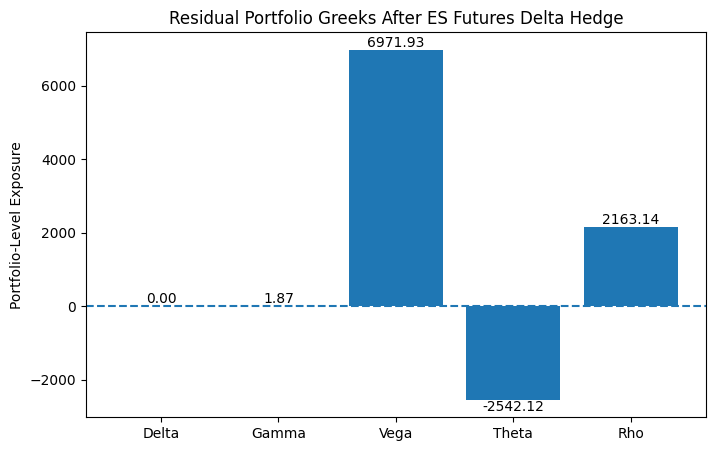

In [55]:
# Residual portfolio Greeks after ES futures delta hedge

residual_delta = total_delta_exposure + hedge_es_contracts * es_multiplier

portfolio_gamma = selected_gamma * contracts * option_multiplier
portfolio_vega = selected_vega * contracts * option_multiplier
portfolio_theta = selected_theta * contracts * option_multiplier
portfolio_rho = selected_rho * contracts * option_multiplier

residual_greeks = pd.DataFrame({
    "Risk Factor": ["Delta", "Gamma", "Vega", "Theta", "Rho"],
    "Portfolio Exposure After Delta Hedge": [
        residual_delta,
        portfolio_gamma,
        portfolio_vega,
        portfolio_theta,
        portfolio_rho
    ]
})

print("=" * 100)
print("RESIDUAL PORTFOLIO GREEKS AFTER ES FUTURES DELTA HEDGE")
print("=" * 100)

display(residual_greeks.round(4))

plt.figure(figsize=(8, 5))

plt.bar(
    residual_greeks["Risk Factor"],
    residual_greeks["Portfolio Exposure After Delta Hedge"]
)

plt.axhline(y=0, linestyle="--")
plt.title("Residual Portfolio Greeks After ES Futures Delta Hedge")
plt.ylabel("Portfolio-Level Exposure")

for i, v in enumerate(residual_greeks["Portfolio Exposure After Delta Hedge"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom" if v >= 0 else "top")

plt.show()

## Scenario Analysis: SPX Shocks and Volatility Shocks

Stress test the Delta-hedged SPX call position under different SPX index shocks and volatility shocks.

Use the same selected near-ATM SPX call and the same ES futures hedge from the previous section.

Scenario inputs:

- SPX index shocks: `-5%`, `-2%`, `0%`, `+2%`, `+5%`
- Volatility shocks: `-5 vol pts`, `0`, `+5 vol pts`

Reprice the call option under each scenario and calculate:

- new option price
- new Delta
- Delta change
- option P&L
- ES futures hedge P&L
- total hedged P&L
- residual Delta exposure

Option P&L:

$$
\text{Option P&L}
=
(\text{Shocked Option Price} - \text{Initial Option Price})
\times
\text{Contracts}
\times
100
$$

ES hedge P&L:

$$
\text{ES Hedge P&L}
=
\text{ES Hedge Contracts}
\times
50
\times
(\text{Shocked SPX} - \text{Initial SPX})
$$

Hedged P&L:

$$
\text{Hedged P&L}
=
\text{Option P&L}
+
\text{ES Hedge P&L}
$$

Residual Delta exposure:

$$
\text{Residual Delta Exposure}
=
\text{New Delta}
\times
\text{Contracts}
\times
100
+
\text{ES Hedge Contracts}
\times
50
$$

Key point:

- At `0%` SPX shock and `0` volatility shock, hedged P&L is close to zero.
- The ES hedge reduces initial Delta exposure, but it does not eliminate Gamma and Vega risk.
- Under larger SPX moves, Delta changes because of Gamma.
- Under volatility shocks, option value changes because of Vega.
- The final chart shows how hedged P&L changes across SPX shocks and volatility shocks.

In [61]:
print("=" * 100)
print("SCENARIO ANALYSIS: SPX SHOCKS AND VOLATILITY SHOCKS")
print("=" * 100)

# Re-select the same near-ATM SPX call option
selected_option = market_greeks_df.sort_values("Distance to Index").iloc[0]

initial_index = spx_price
initial_strike = selected_option["Strike"]

# Use the volatility actually used in the real option-chain Greeks calculation
initial_vol = selected_option["Vol Used (%)"] / 100

# Safety fallback if volatility is missing or unrealistic
if (not pd.notna(initial_vol)) or initial_vol < 0.05 or initial_vol > 1.00:
    initial_vol = hist_vol

r_scenario = 0.04
q_scenario = 0.00
T_scenario = days_to_maturity / 365

# Initial option price under the same assumptions used for scenario analysis
initial_price = black_scholes_call(
    S=initial_index,
    K=initial_strike,
    r=r_scenario,
    sigma=initial_vol,
    T=T_scenario,
    q=q_scenario
)

initial_delta = selected_delta

index_shocks = [-0.05, -0.02, 0.00, 0.02, 0.05]
vol_shocks = [-0.05, 0.00, 0.05]  # absolute volatility shocks: -5 vol pts, 0, +5 vol pts

scenario_results = []

for index_shock in index_shocks:
    for vol_shock in vol_shocks:
        shocked_index = initial_index * (1 + index_shock)
        shocked_vol = max(initial_vol + vol_shock, 0.01)

        shocked_price = black_scholes_call(
            S=shocked_index,
            K=initial_strike,
            r=r_scenario,
            sigma=shocked_vol,
            T=T_scenario,
            q=q_scenario
        )

        shocked_greeks = bsm_greeks(
            S=shocked_index,
            X=initial_strike,
            sigma=shocked_vol,
            r=r_scenario,
            q=q_scenario,
            t=days_to_maturity
        )

        shocked_delta = shocked_greeks["Delta (Call)"]

        option_pnl = (shocked_price - initial_price) * contracts * option_multiplier
        futures_hedge_pnl = hedge_es_contracts * es_multiplier * (shocked_index - initial_index)
        hedged_pnl = option_pnl + futures_hedge_pnl

        residual_delta_exposure = (
            shocked_delta * contracts * option_multiplier
            + hedge_es_contracts * es_multiplier
        )

        scenario_results.append({
            "Index Shock (%)": index_shock * 100,
            "Vol Shock (vol pts)": vol_shock * 100,
            "Shocked SPX": shocked_index,
            "Shocked IV (%)": shocked_vol * 100,
            "New Delta": shocked_delta,
            "Delta Change": shocked_delta - initial_delta,
            "Option P&L": option_pnl,
            "ES Hedge P&L": futures_hedge_pnl,
            "Hedged P&L": hedged_pnl,
            "Residual Delta Exposure": residual_delta_exposure
        })

scenario_df = pd.DataFrame(scenario_results)

display(scenario_df.round(4))

SCENARIO ANALYSIS: SPX SHOCKS AND VOLATILITY SHOCKS


,Index Shock (%),Vol Shock (vol pts),Shocked SPX,Shocked IV (%),New Delta,Delta Change,Option P&L,ES Hedge P&L,Hedged P&L,Residual Delta Exposure
0,-5.0,-5.0,7126.1782,7.1028,0.0017,-0.5371,-93744.5684,202076.7958,108332.2274,-537.1145
1,-5.0,0.0,7126.1782,12.1028,0.0433,-0.4954,-90262.7810,202076.7958,111814.0148,-495.4417
2,-5.0,5.0,7126.1782,17.1028,0.1146,-0.4242,-78138.9591,202076.7958,123937.8367,-424.1646
3,-2.0,-5.0,7351.2154,7.1028,0.1434,-0.3953,-84883.4672,80830.7183,-4052.7489,-395.3487
4,-2.0,0.0,7351.2154,12.1028,0.2690,-0.2698,-60052.2920,80830.7183,20778.4264,-269.7502
5,-2.0,5.0,7351.2154,17.1028,0.3351,-0.2036,-29948.6729,80830.7183,50882.0454,-203.6326
6,0.0,-5.0,7501.2402,7.1028,0.5597,0.0209,-34776.1231,-0.0000,-34776.1231,20.8685
7,0.0,0.0,7501.2402,12.1028,0.5388,0.0000,0.0000,-0.0000,0.0000,0.0000
8,0.0,5.0,7501.2402,17.1028,0.5314,-0.0073,34893.3066,-0.0000,34893.3066,-7.3405
9,2.0,-5.0,7651.2650,7.1028,0.9101,0.3713,79223.8454,-80830.7183,-1606.8729,371.2776


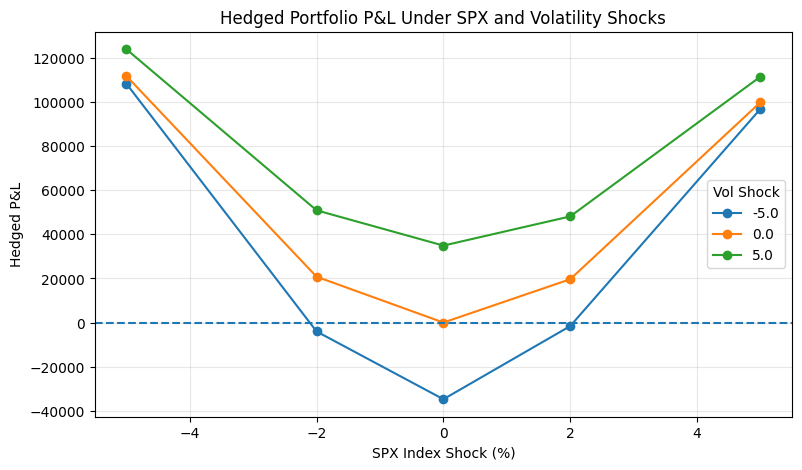

In [62]:
# Plot hedged P&L under index and volatility shocks

pivot_pnl = scenario_df.pivot(
    index="Index Shock (%)",
    columns="Vol Shock (vol pts)",
    values="Hedged P&L"
)

pivot_pnl.plot(marker="o", figsize=(9, 5))

plt.axhline(y=0, linestyle="--")
plt.title("Hedged Portfolio P&L Under SPX and Volatility Shocks")
plt.xlabel("SPX Index Shock (%)")
plt.ylabel("Hedged P&L")
plt.legend(title="Vol Shock")
plt.grid(True, alpha=0.3)
plt.show()

## Summary: Market Risk Takeaways

This project builds a Black-Scholes-based market risk framework for SPX index options.

The project first uses SPX market data to estimate the current index level and 1-year historical volatility. It then defines Black-Scholes pricing functions for European calls and puts and calculates the main option Greeks: Delta, Gamma, Vega, Theta, and Rho.

The Greeks analysis shows how option risk changes across strikes, maturities, and volatility assumptions. Across strikes, Delta changes with moneyness, while Gamma and Vega are highest around ATM. Across maturities and volatility levels, longer-dated options generally have higher Vega exposure, while shorter-dated near-ATM options can have higher Gamma risk.

The project then applies the Greeks framework to a real SPX call option chain and selects a near-ATM SPX call for Delta hedging. The selected call’s Delta is used to estimate portfolio Delta exposure in dollar-per-index-point terms. ES futures are then used to hedge the first-order SPX directional exposure.

The hedge reduces initial Delta exposure to approximately zero, but it does not eliminate the option’s residual risks. Gamma, Vega, Theta, and Rho exposures remain after the ES futures hedge.

The scenario analysis stress tests the hedged portfolio under SPX index shocks and volatility shocks. The results show that Delta-neutral does not mean risk-free. When SPX moves, Delta changes because of Gamma. When volatility changes, option value changes because of Vega.

The main market risk takeaway is to understand which risk has been hedged, which risks remain, and when the hedge needs to be monitored or rebalanced.
